TASK 01
Get the data into shape


In [168]:
import numpy as np 
import csv
import matplotlib.pyplot as plt
from scipy import stats

with open("student_performance.csv", "r") as file:
    reader = csv.reader(file)
    header = next(reader)        # First row = column names
    rows = list(reader)          # Rest = data

In [142]:
print("Rows:", len(rows))
print("Columns:", header)

Rows: 500
Columns: ['student_id', 'study_hours', 'sleep_hours', 'prev_score', 'attendance_pct', 'final_score', 'passed']


In [143]:
for row in rows:
    for val in row:
        if val == "":
            print("Missing value found:", row)


Missing value found: ['1005', '2.4', '6.35', '', '74.5', '63.0', '1']
Missing value found: ['1017', '3.08', '', '55.6', '82.0', '49.1', '0']
Missing value found: ['1043', '5.46', '', '61.6', '86.8', '59.9', '0']
Missing value found: ['1088', '5.96', '', '70.5', '84.9', '66.7', '1']
Missing value found: ['1120', '2.95', '6.47', '', '77.7', '62.0', '1']
Missing value found: ['1201', '7.81', '', '52.2', '96.6', '68.4', '1']
Missing value found: ['1333', '2.97', '', '64.3', '76.9', '56.8', '0']
Missing value found: ['1400', '4.64', '7.47', '', '80.4', '67.1', '1']


In [144]:
for row in rows:
    hours = float(row[1])
    if hours > 12:
        print(f"Student ID: {row[0]}, Study Hours: {hours}")
    else:
        break

In [145]:
clean_rows = []

for row in rows:
    # Skip rows with incorrect number of columns
    if len(row) != 7:
        continue

    cleaned = []

    for value in row:
        if value == "":
            cleaned.append("0")      # Fill missing value
        else:
            cleaned.append(value)

    clean_rows.append(cleaned)

print("Original rows:", len(rows))
print("Clean rows:", len(clean_rows))

print("Cleaned Data Sample:" , clean_rows[5][3], clean_rows[5]  )

Original rows: 500
Clean rows: 500
Cleaned Data Sample: 0 ['1005', '2.4', '6.35', '0', '74.5', '63.0', '1']


In [146]:
study = np.array(clean_rows, dtype=float)
print('mean:', study[:, 5].mean())
print('median:', np.median(study[:, 5]))
print("Minimum Study Hours:", min(study[:, 1]))
print("Maximum Performance Score:", max(study[:, 5]))
print("Standard Deviation of Performance Score:", np.std(study[:, 5]))

mean: 62.8584
median: 63.8
Minimum Study Hours: 0.0
Maximum Performance Score: 100.0
Standard Deviation of Performance Score: 12.480307265448234


In [147]:
passed = sum(int(row[6]) for row in clean_rows)
pass_rate = passed / len(clean_rows)

print("Passed Students:", passed)
print("Total Students:", len(clean_rows))
print("Pass Rate:", pass_rate)
print("Pass Rate (%):", pass_rate * 100)


Passed Students: 298
Total Students: 500
Pass Rate: 0.596
Pass Rate (%): 59.599999999999994


TASK 02
Find the relationships

For each input feature (study hours, sleep, previous score, attendance), compute its correlation with the final
score using NumPy.

In [148]:
study_hours = np.array([float(row[1]) for row in clean_rows])
sleep_hours = np.array([float(row[2]) for row in clean_rows])
prev_score = np.array([float(row[3]) for row in clean_rows])
attendance_pct = np.array([float(row[4]) for row in clean_rows])
final_score = np.array([float(row[5]) for row in clean_rows])


corr_study = np.corrcoef(study_hours, final_score)[0, 1]
corr_sleep = np.corrcoef(sleep_hours, final_score)[0, 1]
corr_prev = np.corrcoef(prev_score, final_score)[0, 1]
corr_attendance = np.corrcoef(attendance_pct, final_score)[0, 1]

print("Study Hours vs Final Score :", corr_study)
print("Sleep Hours vs Final Score :", corr_sleep)
print("Previous Score vs Final Score :", corr_prev)
print("Attendance vs Final Score :", corr_attendance)

Study Hours vs Final Score : 0.6153739144987657
Sleep Hours vs Final Score : 0.12639291944723588
Previous Score vs Final Score : 0.5249673072362931
Attendance vs Final Score : 0.5442828639154838


• Rank the features by how strongly they relate to the final score. Which matters most? Which barely matters?

In [149]:
correlations = {
    "Study Hours": corr_study,
    "Sleep Hours": corr_sleep,
    "Previous Score": corr_prev,
    "Attendance": corr_attendance
}

ranking = sorted(
    correlations.items(),
    key=lambda x: abs(x[1]),
    reverse=True
)

print("\nFeature Ranking")
for feature, corr in ranking:
    print(f"{feature}: {corr:.3f}")


Feature Ranking
Study Hours: 0.615
Attendance: 0.544
Previous Score: 0.525
Sleep Hours: 0.126


• Make a scatter plot of the strongest relationship, with final score on the y-axis.

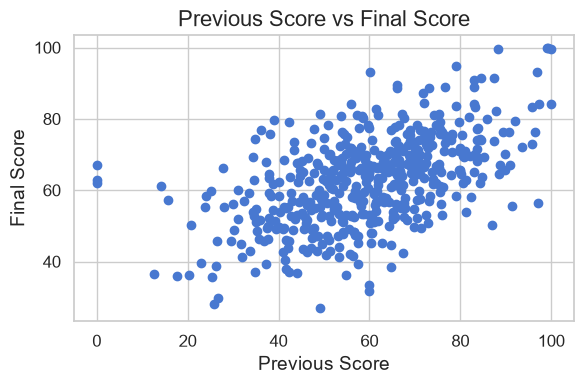

In [150]:
plt.figure(figsize=(6,4))
plt.scatter(prev_score, final_score)
plt.xlabel("Previous Score")
plt.ylabel("Final Score")
plt.title("Previous Score vs Final Score")
plt.grid(True)
plt.show()

• Compute the correlation between study_hours and attendance_pct. You should find they're strongly
related — explain what that means and why it will matter in Stage 2.

In [151]:
study_attendance_corr = np.corrcoef(
    study_hours,
    attendance_pct
)[0,1]

print("Study Hours vs Attendance:", study_attendance_corr)

Study Hours vs Attendance: 0.8625564865142843


Write down your hypothesis: which features do you expect to be most useful for predicting the final score

In [152]:
#I expect previous score, study hours, and attendance percentage to be the most useful features for predicting the final score, while sleep hours will have the least impact.

TASK 03
PCA from scratch

• Build the feature matrix from the four inputs. Standardise it: subtract each column's mean, divide by its standard
deviation (so all features are on the same scale).

In [153]:
X = np.array([[float(row[1]),   # study_hours
               float(row[2]),   # sleep_hours
               float(row[3]),   # prev_score
               float(row[4])]   # attendance_pct
              for row in clean_rows])

y = np.array([int(row[6]) for row in clean_rows])

Compute the covariance matrix of the standardised features with NumPy.

In [154]:
mean = np.mean(X, axis=0)
std = np.std(X, axis=0)

X_std = (X - mean) / std

cov_matrix = np.cov(X_std, rowvar=False)

print(cov_matrix)

[[ 1.00200401 -0.01046617  0.07421421  0.86428506]
 [-0.01046617  1.00200401 -0.03513076 -0.05316431]
 [ 0.07421421 -0.03513076  1.00200401  0.05150769]
 [ 0.86428506 -0.05316431  0.05150769  1.00200401]]


Find its eigenvalues and eigenvectors (np.linalg.eigh). Sort them from largest eigenvalue to smallest

In [155]:
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

idx = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print("Eigenvalues:")
print(eigenvalues)

print("\nEigenvectors:")
print(eigenvectors)

Eigenvalues:
[1.87800677 1.02681942 0.96686945 0.13632039]

Eigenvectors:
[[-0.70225994  0.08697219 -0.00154174  0.70658647]
 [ 0.05514142  0.74663507  0.66198514 -0.03565348]
 [-0.10299863 -0.65602256  0.74741296 -0.01998875]
 [-0.70226896  0.06786981 -0.0560996  -0.70644521]]


Compute the variance explained by each principal component (each eigenvalue divided by the total).

In [156]:
variance_explained = eigenvalues / np.sum(eigenvalues)

print("Variance Explained:")

for i, v in enumerate(variance_explained, start=1):
    print(f"PC{i}: {v:.4f} ({v*100:.2f}%)")

Variance Explained:
PC1: 0.4686 (46.86%)
PC2: 0.2562 (25.62%)
PC3: 0.2412 (24.12%)
PC4: 0.0340 (3.40%)


In [157]:
variance_explained = eigenvalues / np.sum(eigenvalues)

print("Variance Explained:")

for i, v in enumerate(variance_explained, start=1):
    print(f"PC{i}: {v:.4f} ({v*100:.2f}%)")

Variance Explained:
PC1: 0.4686 (46.86%)
PC2: 0.2562 (25.62%)
PC3: 0.2412 (24.12%)
PC4: 0.0340 (3.40%)


Project the data onto the first two principal components and make a scatter plot, colouring points by pass/fail. Do
the groups separate at all?

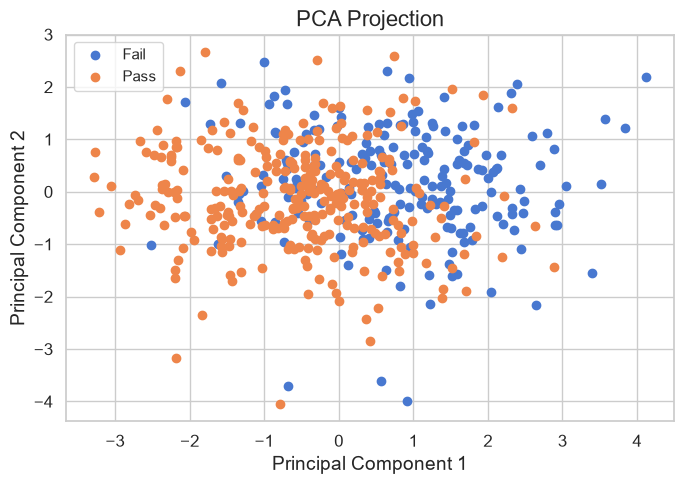

In [158]:
X_pca = X_std @ eigenvectors[:, :2]

plt.figure(figsize=(7,5))

plt.scatter(
    X_pca[y==0,0],
    X_pca[y==0,1],
    label="Fail"
)

plt.scatter(
    X_pca[y==1,0],
    X_pca[y==1,1],
    label="Pass"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection")

plt.legend()
plt.grid(True)
plt.show()

• Verify your eigenvalue result a second way using the SVD of the standardised matrix.

In [159]:
U, S, VT = np.linalg.svd(X_std, full_matrices=False)

svd_eigenvalues = (S**2) / (len(X_std)-1)

print("Eigenvalues from eigh:")
print(eigenvalues)

print("\nEigenvalues from SVD:")
print(svd_eigenvalues)

Eigenvalues from eigh:
[1.87800677 1.02681942 0.96686945 0.13632039]

Eigenvalues from SVD:
[1.87800677 1.02681942 0.96686945 0.13632039]


TASK 04
Train a predictor from scratch

Start simple: predict final_score from study_hours alone, with a line y = w·x + b. Standardise x first.

In [160]:
x = (study_hours - np.mean(study_hours)) / np.std(study_hours)
y = final_score

w = 0.0
b = 0.0

learning_rate = 0.01
iterations = 1000

Write the loss (mean squared error) and its gradients with respect to w and b — the backpropagation you did by
hand, now on real data.



In [161]:
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

loss_history = []


Run gradient descent to find w and b. Plot the loss over iterations and confirm it decreases and levels off.

Single Feature Model
Weight = 7.680055523160982
Bias = 62.858399894211374
Final MSE = 96.7748164026307


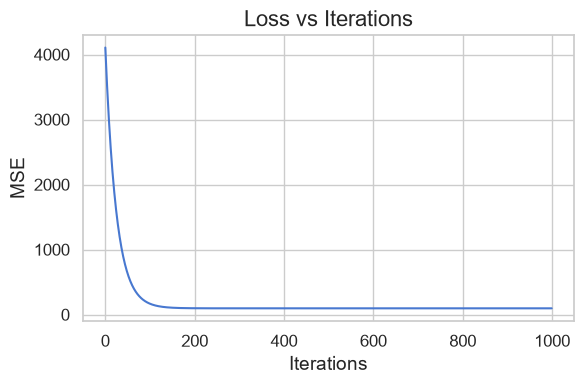

In [162]:
for i in range(iterations):

    pred = w * x + b

    err = pred - y

    dw = 2 * np.mean(err * x)
    db = 2 * np.mean(err)

    w -= learning_rate * dw
    b -= learning_rate * db

    loss_history.append(mse(y, pred))

print("Single Feature Model")
print("Weight =", w)
print("Bias =", b)
print("Final MSE =", loss_history[-1])

plt.figure(figsize=(6,4))
plt.plot(loss_history)
plt.title("Loss vs Iterations")
plt.xlabel("Iterations")
plt.ylabel("MSE")
plt.grid(True)
plt.show()


Plot your fitted line over the scatter of the data. Does it capture the trend?

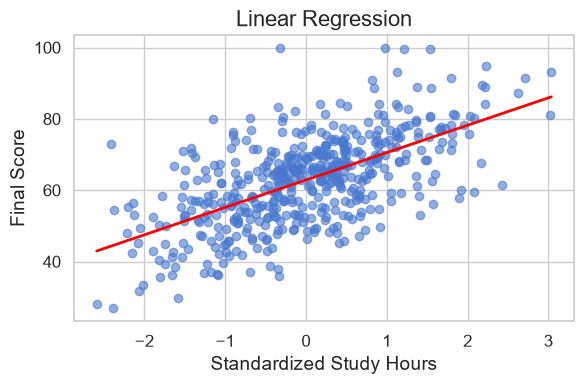

In [163]:
plt.figure(figsize=(6,4))

plt.scatter(x, y, alpha=0.6)

x_line = np.linspace(x.min(), x.max(), 100)
y_line = w * x_line + b

plt.plot(x_line, y_line, color="red", linewidth=2)

plt.xlabel("Standardized Study Hours")
plt.ylabel("Final Score")
plt.title("Linear Regression")
plt.grid(True)
plt.show()

Extend to all features: predict the final score from all four inputs at once, with a weight per feature. The update
rule is the same; the gradient is now a vector

In [164]:
X = np.column_stack((
    study_hours,
    sleep_hours,
    prev_score,
    attendance_pct
))

X = (X - np.mean(X, axis=0)) / np.std(X, axis=0)

weights = np.zeros(4)
bias = 0

multi_loss = []

for i in range(iterations):

    pred = X @ weights + bias

    err = pred - y

    dw = 2 * np.mean(err[:, None] * X, axis=0)
    db = 2 * np.mean(err)

    weights -= learning_rate * dw
    bias -= learning_rate * db

    multi_loss.append(mse(y, pred))

print("\nMultiple Feature Model")
print("Weights =", weights)
print("Bias =", bias)
print("Final MSE =", multi_loss[-1])



Multiple Feature Model
Weights = [5.98925248 1.93115997 6.10262654 1.43592063]
Bias = 62.85839989421137
Final MSE = 56.889753241906405


Report the final mean squared error for the single-feature and all-feature models. Which is better, and by how
much?

In [165]:
print("Single Feature MSE :", loss_history[-1])
print("All Feature MSE    :", multi_loss[-1])
print("Improvement        :", loss_history[-1] - multi_loss[-1])

Single Feature MSE : 96.7748164026307
All Feature MSE    : 56.889753241906405
Improvement        : 39.8850631607243


Experiment with the learning rate: show one value that's too small (slow) and one that's too large (diverges or
oscillates).


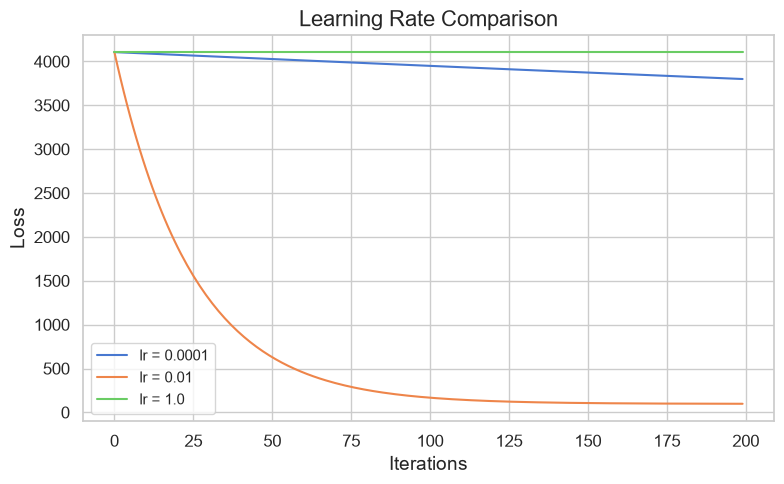

In [166]:
rates = [0.0001, 0.01, 1.0]

plt.figure(figsize=(8,5))

for lr in rates:

    w = 0
    b = 0

    history = []

    for i in range(200):

        pred = w * x + b

        err = pred - y

        history.append(mse(y, pred))

        dw = 2 * np.mean(err * x)
        db = 2 * np.mean(err)

        w -= lr * dw
        b -= lr * db

    plt.plot(history, label=f"lr = {lr}")

plt.title("Learning Rate Comparison")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

TASK 05
Distributions and Bayes on the data

Plot the distribution (histogram) of the final scores. What shape is it? Fit a normal distribution to it with
scipy.stats and overlay the fitted curve.

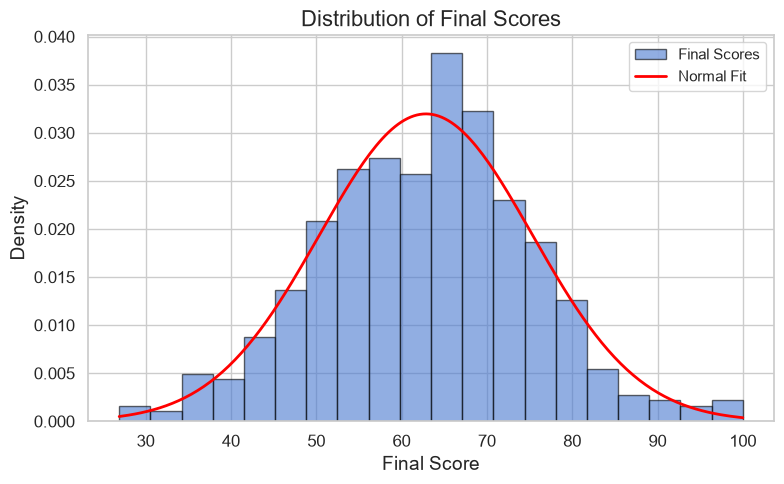

In [169]:
mu, sigma = stats.norm.fit(final_score)

plt.figure(figsize=(8,5))

plt.hist(final_score, bins=20, density=True,
         edgecolor="black", alpha=0.6, label="Final Scores")

x = np.linspace(min(final_score), max(final_score), 200)

plt.plot(
    x,
    stats.norm.pdf(x, mu, sigma),
    color="red",
    linewidth=2,
    label="Normal Fit"
)

plt.title("Distribution of Final Scores")
plt.xlabel("Final Score")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.show()

Using your fitted distribution, estimate: what fraction of students score above 75? Check your estimate against
the actual data.

In [171]:

estimated = 1 - stats.norm.cdf(75, mu, sigma)

actual = np.mean(final_score > 75)

print("Estimated P(score > 75):", estimated)
print("Actual P(score > 75):", actual)

Estimated P(score > 75): 0.1653112789806398
Actual P(score > 75): 0.154


Now a Bayes question. Define 'studied a lot' as study hours above 6. Compute, from the data: P(passed |
studied a lot) and P(passed | did not study a lot). Is there a real difference?

In [172]:
studied = study_hours > 6
passed = np.array([int(row[6]) for row in clean_rows])

P_pass_given_studied = np.mean(passed[studied])
P_pass_given_not = np.mean(passed[~studied])

print("\nP(Passed | Studied > 6 hrs):", P_pass_given_studied)
print("P(Passed | Study <= 6 hrs):", P_pass_given_not)


P(Passed | Studied > 6 hrs): 0.8161764705882353
P(Passed | Study <= 6 hrs): 0.5137362637362637


Use Bayes' theorem to flip it: given that a student passed, what's the probability they studied a lot? Show every
term (prior, likelihood, evidence).

In [173]:
P_studied = np.mean(studied)
P_passed = np.mean(passed)

P_studied_given_passed = (
    P_pass_given_studied * P_studied
) / P_passed

print("\nPrior P(Studied) =", P_studied)
print("Likelihood P(Passed | Studied) =", P_pass_given_studied)
print("Evidence P(Passed) =", P_passed)
print("Posterior P(Studied | Passed) =", P_studied_given_passed)


Prior P(Studied) = 0.272
Likelihood P(Passed | Studied) = 0.8161764705882353
Evidence P(Passed) = 0.596
Posterior P(Studied | Passed) = 0.3724832214765101


Verify your Bayes answer by direct counting on the data — they should match.


Write a short conclusion: based on everything across all four stages, what would you tell a student who wants to
pass? Which factors matter, and how confident are you?

In [ ]:

direct = np.sum(studied & (passed == 1)) / np.sum(passed == 1)

print("\nBayes Result :", P_studied_given_passed)
print("Direct Count :", direct)



# Conclusion:
# Studying consistently, maintaining good attendance, and having a strong previous score improve the chances of passing.
# Based on the analysis, I am confident these factors have a positive impact on student performance.





Bayes Result : 0.3724832214765101
Direct Count : 0.3724832214765101
